<center><img src='https://drive.google.com/uc?id=1_utx_ZGclmCwNttSe40kYA6VHzNocdET' height="60"></center>

AI TECH - Akademia Innowacyjnych Zastosowań Technologii Cyfrowych. Program Operacyjny Polska Cyfrowa na lata 2014-2020
<hr>

<center><img src='https://drive.google.com/uc?id=1BXZ0u3562N_MqCLcekI-Ens77Kk4LpPm'></center>

<center>
Projekt współfinansowany ze środków Unii Europejskiej w ramach Europejskiego Funduszu Rozwoju Regionalnego
Program Operacyjny Polska Cyfrowa na lata 2014-2020,
Oś Priorytetowa nr 3 "Cyfrowe kompetencje społeczeństwa" Działanie  nr 3.2 "Innowacyjne rozwiązania na rzecz aktywizacji cyfrowej"
Tytuł projektu:  „Akademia Innowacyjnych Zastosowań Technologii Cyfrowych (AI Tech)”
    </center>

# Lab 1: Data analysis
In this lab, you will build a machine learning model to predict prices of flats (apartments).

In [531]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Dataset

Each row represents a property listing. Our goal is to train a model that predicts a property's target `price` (the last column) based on its input features (the remaining columns).

Use the train file for all data analysis, cleaning, feature engineering, and model training. All preprocessing decisions must be derived **only** from this dataset.<br>
The test file represents unseen data, it must be used exclusively for evaluating the final model's performance. Knowing it makes prediction trivial. Even small decisions based on it would constitute data leakage.

In [532]:
!wget --no-verbose -O lab1_apartments_train.csv https://mimuw.edu.pl/~mwrochna/upload/lab1_apartments_train.csv
!wget --no-verbose -O lab1_apartments_test.csv https://mimuw.edu.pl/~mwrochna/upload/lab1_apartments_test.csv
!head lab1_apartments_train.csv lab1_apartments_test.csv

2026-10-04 13:48:05 URL:https://mimuw.edu.pl/~mwrochna/upload/lab1_apartments_train.csv [8292/8292] -> "lab1_apartments_train.csv" [1]
2026-10-04 13:48:06 URL:https://mimuw.edu.pl/~mwrochna/upload/lab1_apartments_test.csv [6814/6814] -> "lab1_apartments_test.csv" [1]
==> lab1_apartments_train.csv <==
area,district,bedrooms,bathrooms,build_year,parking,price
104.0,mokotowo,2.0,2,1940,1,780094.0
43.0,ochotowo,1.0,1,1970,1,346912.0
128.0,grodziskowo,3.0,2,1916,1,523466.0
112.0,mokotowo,3.0,2,1920,1,830965.0
149.0,mokotowo,3.0,3,1977,0,1090479.0
80.0,ochotowo,2.0,2,1937,0,599060.0
58.0,ochotowo,2.0,1,1922,0,463639.0
23.0,ochotowo,1.0,1,1929,0,166785.0
40.0,mokotowo,1.0,1,1973,0,318849.0

==> lab1_apartments_test.csv <==
area,district,bedrooms,bathrooms,build_year,parking,price
71,wolowo,2,2,1912,1,322227.0
45,mokotowo,1,1,1938,0,295878.0
38,mokotowo,1,1,1999,1,306530.0
70,ochotowo,2,2,1980,1,553641.0
136,mokotowo,3,2,1939,1,985348.0
128,wolowo,3,2,1983,1,695726.0
23,grodziskowo,1,1,1975,0,

In [533]:
train_df = pd.read_csv("lab1_apartments_train.csv")
test_df = pd.read_csv("lab1_apartments_test.csv")

train_df

,area,district,bedrooms,bathrooms,build_year,parking,price
0,104.0,mokotowo,2.0,2,1940,1,7.800940e+05
1,43.0,ochotowo,1.0,1,1970,1,3.469120e+05
2,128.0,grodziskowo,3.0,2,1916,1,5.234660e+05
3,112.0,mokotowo,3.0,2,1920,1,8.309650e+05
4,149.0,mokotowo,3.0,3,1977,0,1.090479e+06
...,...,...,...,...,...,...,...
217,80.0,ochootowo,2.0,2,1937,0,5.990600e+05
218,72.0,grodziskowo,3.0,1,2034,1,3.907637e+05
219,84.0,ochotowo,2.0,1,2031,0,5.679256e+05
220,0.0,grodziskowo,1.0,1,2004,1,4.496779e+05


## Exploratory Data Analysis (EDA)

Your first goal is to get your hands dirty with `train_df` — raw datasets are rarely clean. Your model's performance depends on how well you understand and validate the data.

Use [Pandas](https://pandas.pydata.org/docs/reference/frame.html), [Matplotlib](https://matplotlib.org/stable/plot_types/index.html), or [Seaborn](https://seaborn.pydata.org/tutorial/introduction.html) to find issues in the dataset.
Take time to write your own exploration code and document what anomalies you spot.
You will need to address them in the next step!

<details markdown="1">
<summary>Hints</summary>

* [pd.DataFrame.describe()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)
* [isna()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html)
* [value_counts()](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html)
* [duplicated()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.duplicated.html)
* [hist()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.hist.html) or [plt.hist()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html)
* [seaborn.pairplot()](https://seaborn.pydata.org/generated/seaborn.pairplot.html) or [plt.scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)

</details>

In [534]:
### TODO ###
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area        220 non-null    float64
 1   district    222 non-null    object 
 2   bedrooms    220 non-null    float64
 3   bathrooms   222 non-null    int64  
 4   build_year  222 non-null    int64  
 5   parking     222 non-null    int64  
 6   price       222 non-null    float64
dtypes: float64(3), int64(3), object(1)
memory usage: 12.3+ KB


In [535]:
train_df.describe()

,area,bedrooms,bathrooms,build_year,parking,price
count,220.000000,220.000000,222.000000,222.000000,222.000000,2.220000e+02
mean,81.522727,2.445455,1.648649,1963.445946,0.513514,5.219942e+05
std,39.292422,6.650555,0.667929,31.070847,0.500947,3.606854e+05
min,0.000000,1.000000,1.000000,1912.000000,0.000000,-6.745005e+04
25%,50.000000,1.000000,1.000000,1937.000000,0.000000,3.046940e+05
50%,77.000000,2.000000,2.000000,1962.000000,1.000000,4.702745e+05
75%,111.250000,3.000000,2.000000,1992.000000,1.000000,6.682392e+05
max,205.000000,100.000000,5.000000,2034.000000,1.000000,3.894993e+06


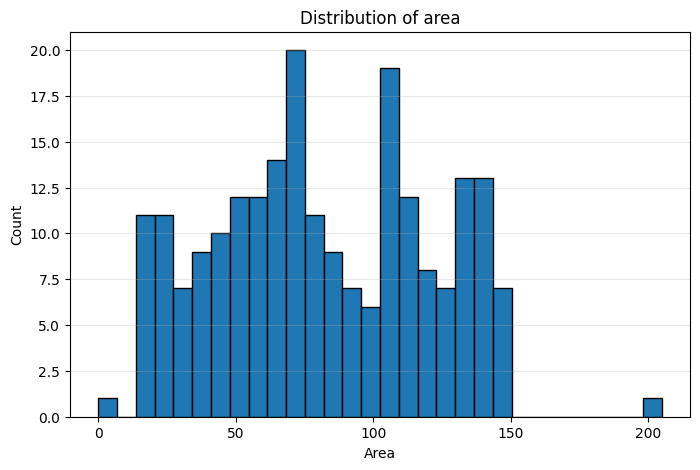

In [536]:
plt.figure(figsize=(8, 5))
plt.hist(train_df['area'], bins=30, edgecolor='black')
plt.xlabel('Area')
plt.ylabel('Count')
plt.title('Distribution of area')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [537]:
train_df['bedrooms'].value_counts()

,count
bedrooms,
2.0,96
1.0,62
3.0,60
4.0,1
100.0,1


In [538]:
train_df['bathrooms'].value_counts()

,count
bathrooms,
2,104
1,99
3,18
5,1


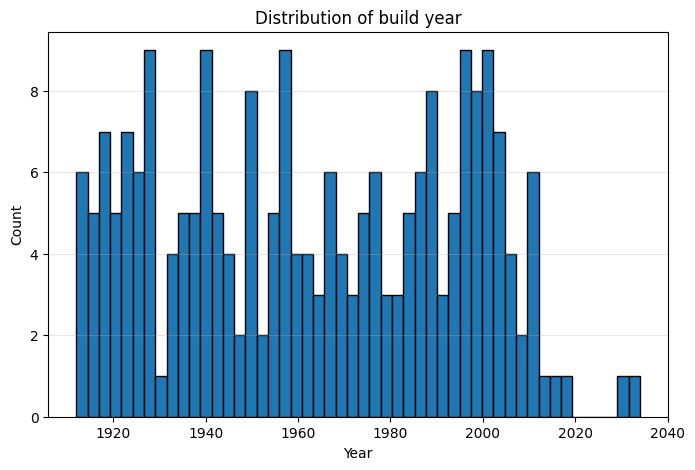

In [539]:
plt.figure(figsize=(8, 5))
plt.hist(train_df['build_year'], bins=50, edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Distribution of build year')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [540]:
train_df['parking'].value_counts()

,count
parking,
1,114
0,108


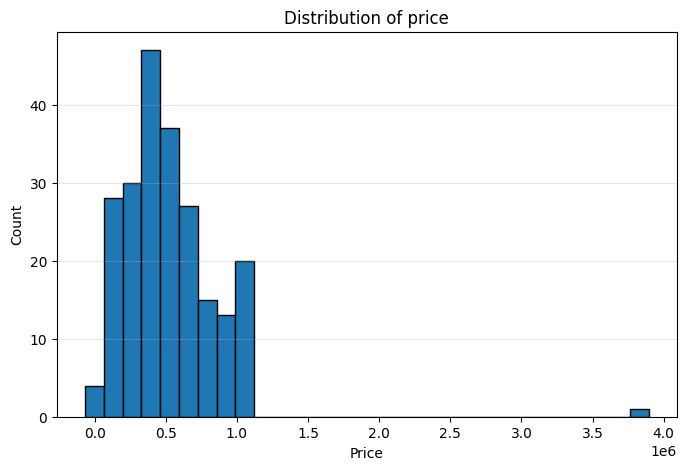

In [541]:
plt.figure(figsize=(8, 5))
plt.hist(train_df['price'], bins=30, edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Distribution of price')
plt.grid(axis='y', alpha=0.3)
plt.show()

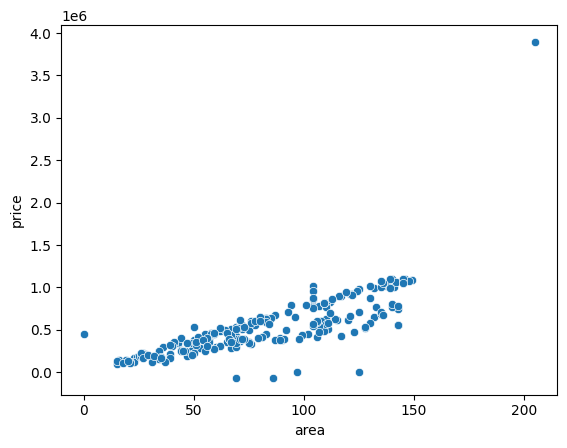

In [542]:
sns.scatterplot(data=train_df, x='area', y='price')
plt.show()

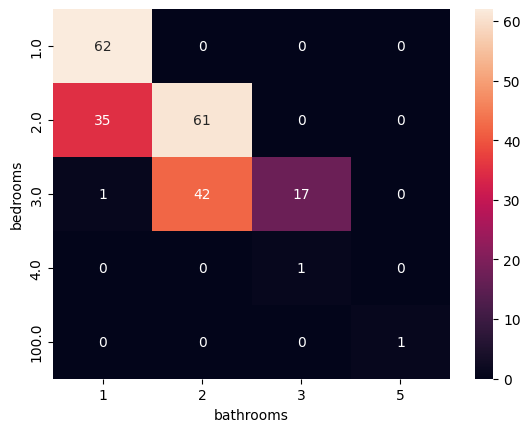

In [543]:
counts = pd.crosstab(train_df['bedrooms'], train_df['bathrooms'])

sns.heatmap(counts, annot=True, fmt='d')
plt.show()

In [544]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area        205 non-null    int64  
 1   district    205 non-null    object 
 2   bedrooms    205 non-null    int64  
 3   bathrooms   205 non-null    int64  
 4   build_year  205 non-null    int64  
 5   parking     205 non-null    int64  
 6   price       205 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 11.3+ KB


In [545]:
test_df.describe()

,area,bedrooms,bathrooms,build_year,parking,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,2.050000e+02
mean,88.204878,2.156098,1.741463,1963.404878,0.580488,5.573860e+05
std,37.738094,0.776508,0.591183,30.262041,0.494687,2.871799e+05
min,16.000000,1.000000,1.000000,1910.000000,0.000000,5.744100e+04
25%,57.000000,2.000000,1.000000,1938.000000,0.000000,3.301520e+05
50%,93.000000,2.000000,2.000000,1965.000000,1.000000,5.272880e+05
75%,120.000000,3.000000,2.000000,1987.000000,1.000000,7.899610e+05
max,149.000000,4.000000,3.000000,2015.000000,1.000000,1.185932e+06


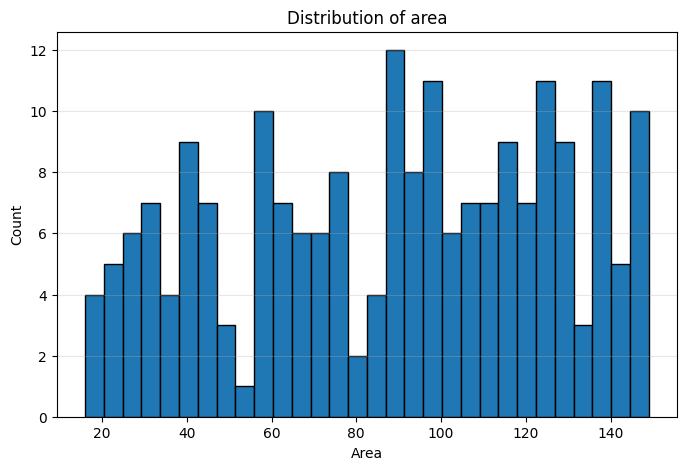

In [546]:
plt.figure(figsize=(8, 5))
plt.hist(test_df['area'], bins=30, edgecolor='black')
plt.xlabel('Area')
plt.ylabel('Count')
plt.title('Distribution of area')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [547]:
test_df['bedrooms'].value_counts()

,count
bedrooms,
2,83
3,74
1,46
4,2


In [548]:
test_df['bathrooms'].value_counts()

,count
bathrooms,
2,120
1,69
3,16


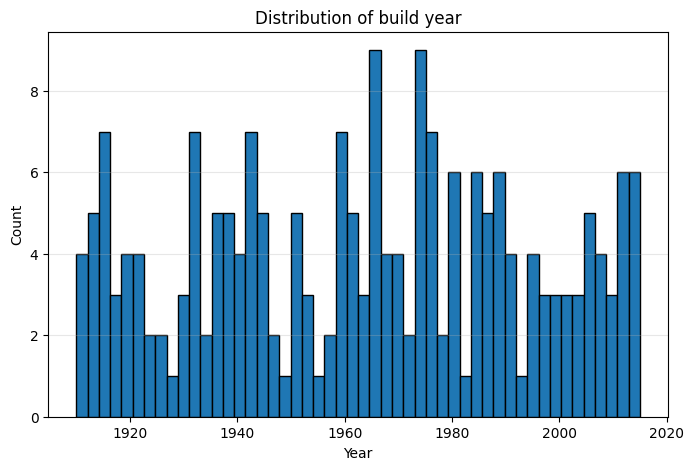

In [549]:
plt.figure(figsize=(8, 5))
plt.hist(test_df['build_year'], bins=50, edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Distribution of build year')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [550]:
test_df['parking'].value_counts()

,count
parking,
1,119
0,86


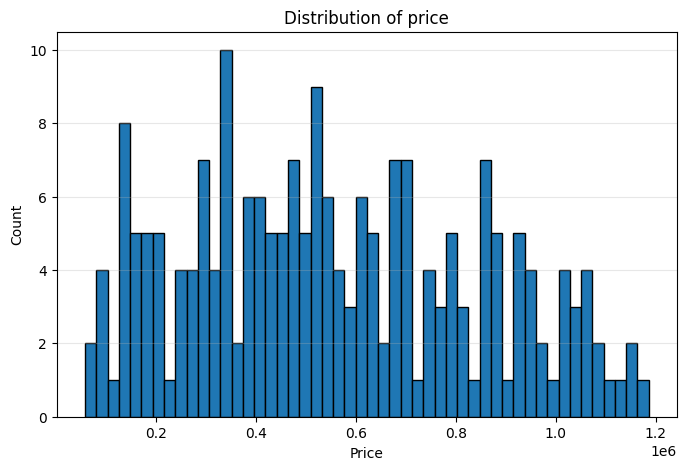

In [551]:
plt.figure(figsize=(8, 5))
plt.hist(test_df['price'], bins=50, edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Distribution of price')
plt.grid(axis='y', alpha=0.3)
plt.show()

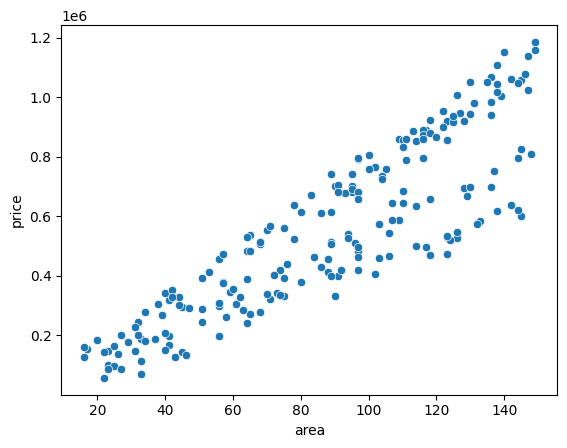

In [552]:
sns.scatterplot(data=test_df, x='area', y='price')
plt.show()

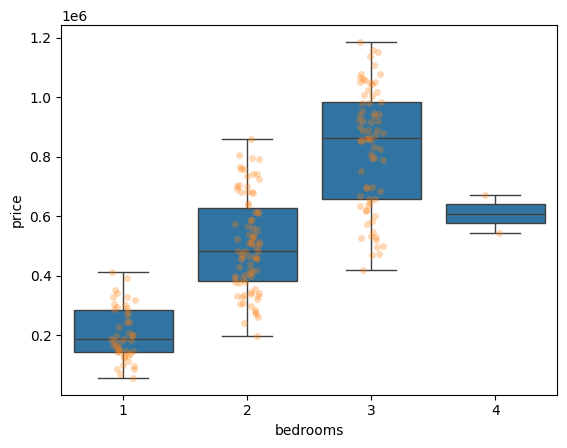

In [553]:
sns.boxplot(data=test_df, x='bedrooms', y='price')
sns.stripplot(
    data=test_df,
    x='bedrooms',
    y='price',
    alpha=0.3
)
plt.show()

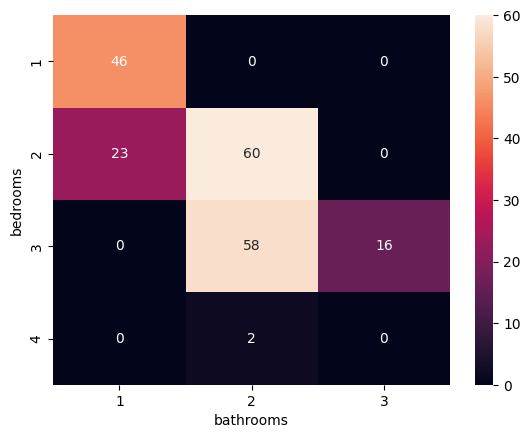

In [554]:
counts = pd.crosstab(test_df['bedrooms'], test_df['bathrooms'])

sns.heatmap(counts, annot=True, fmt='d')
plt.show()

## Data cleaning

Discuss how each issue can be addressed.

As a shortcut, here we can drop the last few rows to make the dataset clean.
In reality you would use `df.dropna()`, `fillna()`, `drop_duplicates()`, `groupby().mean()`, `clamp()`, filters like `df = df[df["price"] > 0]`,and more complex operations.

Note that in a cleaning pipeline:
* row filtering and target sanitization (e.g., dropping negative prices, removing extreme target outliers, or handling label noise) should usually only be performed on the training set.
* feature transformations (e.g., string normalization) must be applicable to both training and unseen test sets.

In [555]:
train_df_clean = train_df.head(200).copy()
test_df_clean = test_df.copy()

train_df_clean.drop_duplicates(inplace=True)

train_df_clean = train_df_clean.loc[
    (train_df_clean['area'] > 0) &
    (train_df_clean['area'] < 200) &
    (train_df_clean['bedrooms'] != 100) &
    (train_df_clean['build_year'] < 2020) &
    (train_df_clean['price'] > 0)
  ]

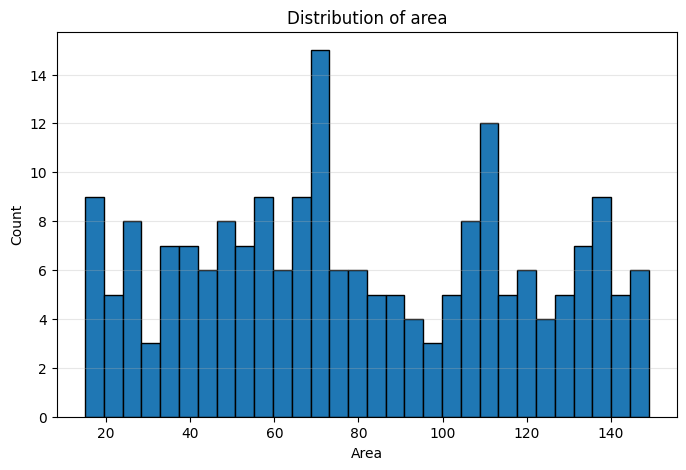

In [556]:
plt.figure(figsize=(8, 5))
plt.hist(train_df_clean['area'], bins=30, edgecolor='black')
plt.xlabel('Area')
plt.ylabel('Count')
plt.title('Distribution of area')
plt.grid(axis='y', alpha=0.3)
plt.show()

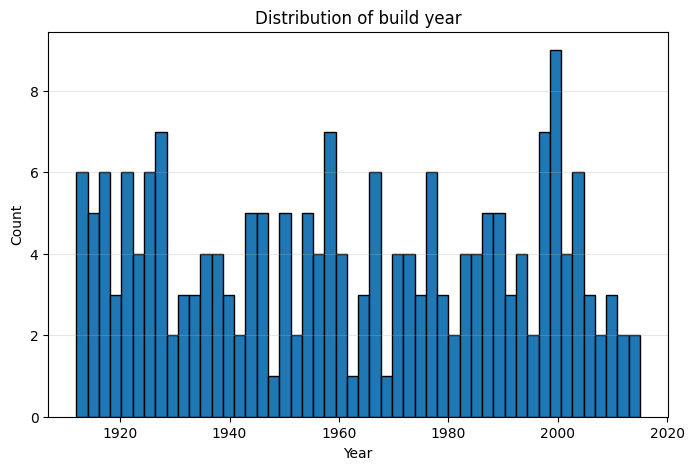

In [557]:
plt.figure(figsize=(8, 5))
plt.hist(train_df_clean['build_year'], bins=50, edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Distribution of build year')
plt.grid(axis='y', alpha=0.3)
plt.show()

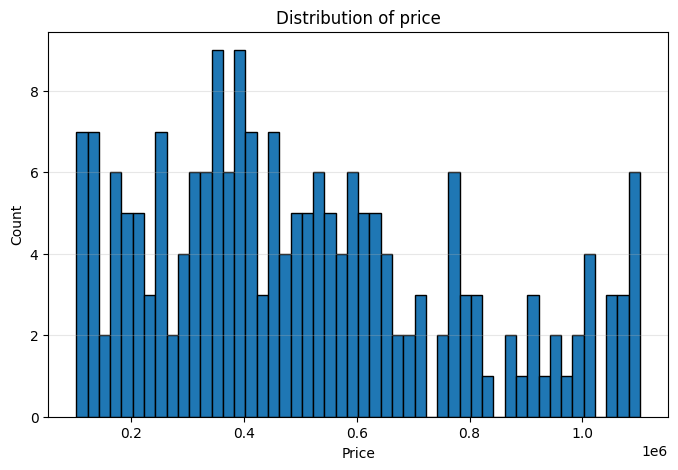

In [558]:
plt.figure(figsize=(8, 5))
plt.hist(train_df_clean['price'], bins=50, edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Distribution of price')
plt.grid(axis='y', alpha=0.3)
plt.show()

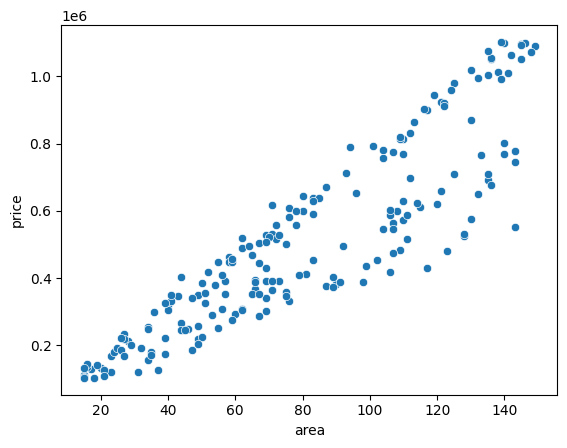

In [559]:
sns.scatterplot(data=train_df_clean, x='area', y='price')
plt.show()

In [560]:
train_df_clean['district'].value_counts()

,count
district,
ochotowo,54
wolowo,50
mokotowo,49
grodziskowo,47


## Encoding categorical features

Machine learning algorithms require numerical inputs. We need to convert categorical string features like `district` into numerical representations.

We will use *ordinal encoding* here for simplicity (a single column with integer values).
Modeling a linear relationship from such ordinal values is not ideal (it wouldn't make sense to say that `district #3` is three times `district #1`), so in reality we'd better use *one-hot encoding* (a separate binary column for each category) to represent such unstructured values.

> Our test set contains an unseen district (`'wawer'`) that does not appear in the training set. We use [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html) configured with `handle_unknown='use_encoded_value'` and `unknown_value=-1` to safely handle out-of-vocabulary categories without breaking the pipeline.

In [561]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

train_df_clean['district_embedded'] = encoder.fit_transform(train_df_clean[['district']])
test_df_clean['district_embedded'] = encoder.transform(test_df_clean[['district']])

## Separating features ($X$) and target ($y$)

By convention in machine learning literature and `scikit-learn`, we denote:

* $X$ (feature matrix): input features (predictors) as a 2D array/DataFrame where each row represents a property listing and each column represents an input feature (e.g., `area`, `bedrooms`, `build_year`, `district_encoded`).
* $y$ (target vector): the target variable, as a 1D array/Series containing the target values we want our model to predict (`price`). Lowercase $y$ is used because it represents a 1D vector.

> **Remember:** Ensure that `X_train` and `X_test` contain the exact same set of feature columns in the exact same order before passing them into the model.

In [562]:
feature_cols = [
    "area",
    "build_year",
    "district_embedded",
    "bedrooms",
    "bathrooms",
    "parking",
]

### TODO ###
X_train = train_df_clean[feature_cols].to_numpy()
y_train = train_df_clean['price'].to_numpy()

X_test = test_df_clean[feature_cols].to_numpy()
y_test = test_df_clean['price'].to_numpy()


print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(200, 6) (200,)
(205, 6) (205,)


## Model training & eval

We can now fit our baseline Ordinary Least Squares (OLS) linear regression model using `scikit-learn`:

1. Model Fitting (`.fit()`): the algorithm learns weights ($w$) for each feature and a bias term ($b$) by minimizing MSE.
2. Prediction (`.predict()`): generate target predictions for both training and held-out test sets.
3. Model Evaluation: measure model performance using standard regression metrics:
   * Mean Absolute Error (MAE)
   * Root Mean Squared Error (RMSE)
   * $R^2$ Score (Coefficient of Determination): proportion of price variance explained by the model ($1.0$ indicates a perfect fit, $0.0$ indicates performance no better than predicting the average price).

In [563]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lm = LinearRegression()
lm.fit(X_train, y_train)
predicted_train = lm.predict(X_train)
predicted_test = lm.predict(X_test)

print("Train:")
print(f"MAE:  {mean_absolute_error(y_train, predicted_train):.2e}")
print(f"RMSE: {mean_squared_error(y_train, predicted_train) ** 0.5:.2e}")
print(f"R2:   {r2_score(y_train, predicted_train):.2e}")

print("\nTest:")
print(f"MAE:  {mean_absolute_error(y_test, predicted_test):.2e}")
print(f"RMSE: {mean_squared_error(y_test, predicted_test) ** 0.5:.2e}")
print(f"R2:   {r2_score(y_test, predicted_test):.2e}")


Train:
MAE:  9.87e+04
RMSE: 1.17e+05
R2:   8.15e-01

Test:
MAE:  1.16e+05
RMSE: 1.32e+05
R2:   7.88e-01


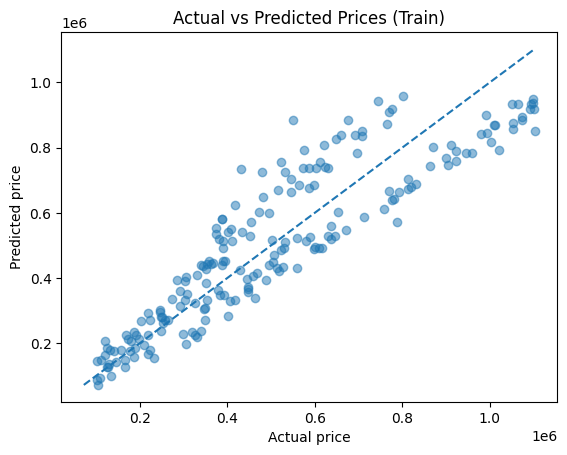

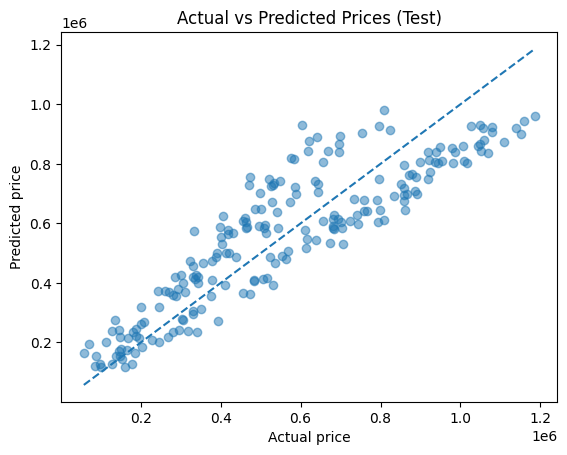

In [564]:
plt.scatter(y_train, predicted_train, alpha=0.5)

lims = [
    min(y_train.min(), predicted_train.min()),
    max(y_train.max(), predicted_train.max())
]
plt.plot(lims, lims, '--')

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted Prices (Train)")
plt.show()


plt.scatter(y_test, predicted_test, alpha=0.5)

lims = [
    min(y_test.min(), predicted_test.min()),
    max(y_test.max(), predicted_test.max())
]
plt.plot(lims, lims, '--')

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted Prices (Test)")
plt.show()

Plot histogram of residuals (prediction errors).

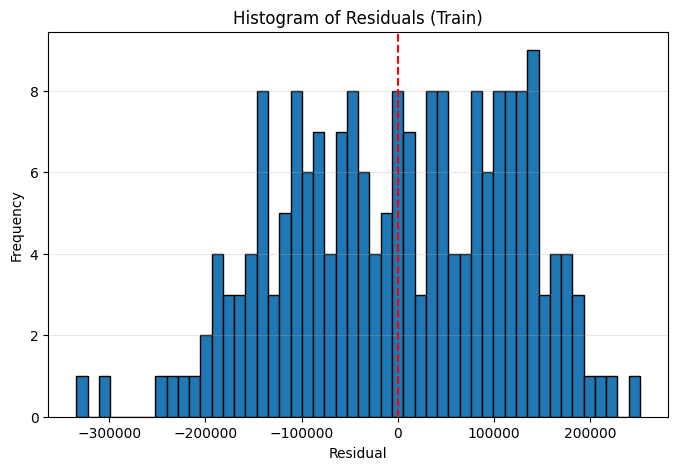

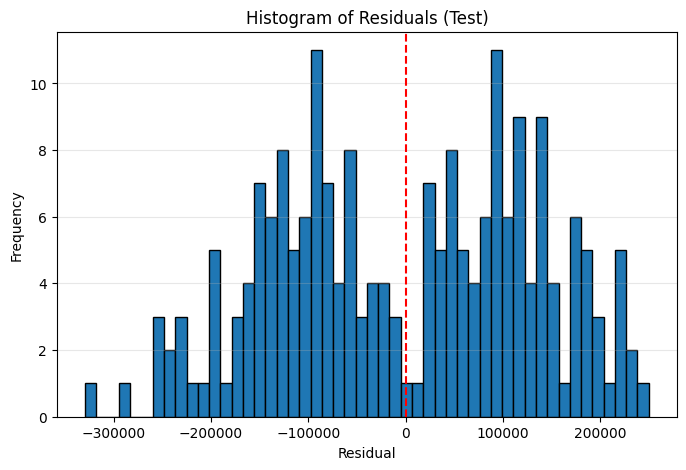

In [565]:
plt.figure(figsize=(8, 5))
plt.hist(y_train - predicted_train, bins=50, edgecolor='black')
plt.axvline(0, linestyle="--", color='red')

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.title("Histogram of Residuals (Train)")

plt.show()

plt.figure(figsize=(8, 5))
plt.hist(y_test - predicted_test, bins=50, edgecolor='black')
plt.axvline(0, linestyle="--", color='red')

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.title("Histogram of Residuals (Test)")

plt.show()

## Feature Engineering

A linear baseline model approximates the house price as a simple weighted combination of raw features:
$$
\text{price} \approx w_1 \cdot \text{area} + w_2 \cdot \text{rooms} + \dots + b
$$

However, we can choose to engineer additional features to model reality better and to allow a linear model to capture feature interactions.
For example, we can propose that prices are driven mostly by area and the average price per square meter within each district.
$$
\text{price} \approx w_1 \cdot \left( \text{area} \cdot \text{avg\textunderscore{}price\textunderscore{}per\textunderscore{}m2}_{\text{district}} \right) + w_2 \cdot \text{rooms} + \dots + b
$$

* Add some feature engineering to your model. You can start by manually computing the district averages and adding a new feature with the basic prediction: $\text{area} \cdot \text{avg}_{\text{district}}$.
* Think how to make your model capable of capturing the $w_1 \cdot \text{area} \cdot \text{avg}$ part without actually computing the averages yourself.
* Can you make a generic transformation that would allow this to work without any presupposed knowledge of what the features mean?

<details markdown="1">
<summary>Hint</summary>

* [pd.Series.map()](https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html) can take a dict saying how each value should be replaced.

</details>

#### Hand-engineered solution

In [566]:
### TODO ###

district_to_average = {}

for district in train_df_clean['district'].unique():
    relevant = train_df_clean.loc[train_df_clean['district'] == district]
    district_to_average[district] = (
        relevant['price'].sum() / relevant['area'].sum()
    )

global_avg = train_df_clean['price'].sum() / train_df_clean['area'].sum()

handed_engineered_train = train_df_clean.copy()
handed_engineered_test = test_df_clean.copy()

handed_engineered_train['area_times_district_avg'] = (
    handed_engineered_train['area']
    * handed_engineered_train['district'].map(district_to_average)
)

handed_engineered_test['area_times_district_avg'] = (
    handed_engineered_test['area']
    * handed_engineered_test['district'].map(district_to_average).fillna(global_avg)
)

In [567]:
feature_cols_handed_engineered = [
    "area",
    "build_year",
    "area_times_district_avg",
    "district_embedded",
    "bedrooms",
    "bathrooms",
    "parking"
]

X_train = handed_engineered_train[feature_cols_handed_engineered].to_numpy()
X_test = handed_engineered_test[feature_cols_handed_engineered].to_numpy()

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(200, 7) (200,)
(205, 7) (205,)


In [568]:
lm = LinearRegression()
lm.fit(X_train, y_train)
predicted_train = lm.predict(X_train)
predicted_test = lm.predict(X_test)

print("Train:")
print(f"MAE:  {mean_absolute_error(y_train, predicted_train):.2e}")
print(f"RMSE: {mean_squared_error(y_train, predicted_train) ** 0.5:.2e}")
print(f"R2:   {r2_score(y_train, predicted_train):.2e}")

print("\nTest:")
print(f"MAE:  {mean_absolute_error(y_test, predicted_test):.2e}")
print(f"RMSE: {mean_squared_error(y_test, predicted_test) ** 0.5:.2e}")
print(f"R2:   {r2_score(y_test, predicted_test):.2e}")


Train:
MAE:  2.27e+04
RMSE: 2.85e+04
R2:   9.89e-01

Test:
MAE:  2.79e+04
RMSE: 3.76e+04
R2:   9.83e-01


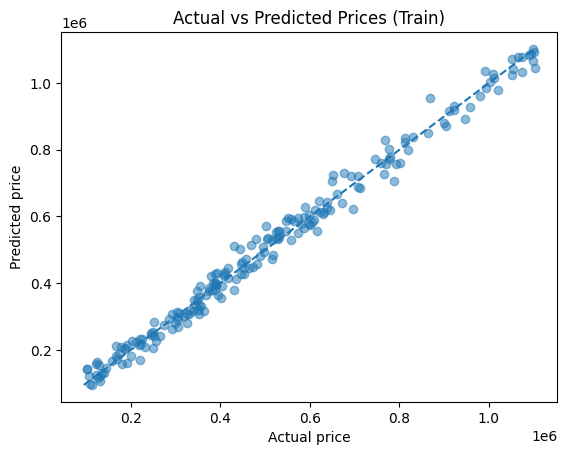

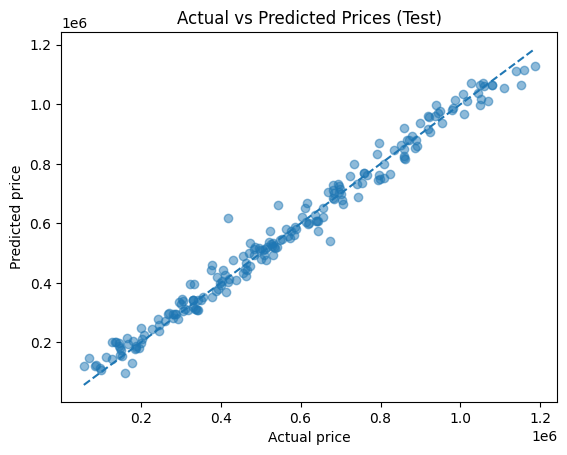

In [569]:
plt.scatter(y_train, predicted_train, alpha=0.5)

lims = [
    min(y_train.min(), predicted_train.min()),
    max(y_train.max(), predicted_train.max())
]
plt.plot(lims, lims, '--')

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted Prices (Train)")
plt.show()


plt.scatter(y_test, predicted_test, alpha=0.5)

lims = [
    min(y_test.min(), predicted_test.min()),
    max(y_test.max(), predicted_test.max())
]
plt.plot(lims, lims, '--')

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted Prices (Test)")
plt.show()

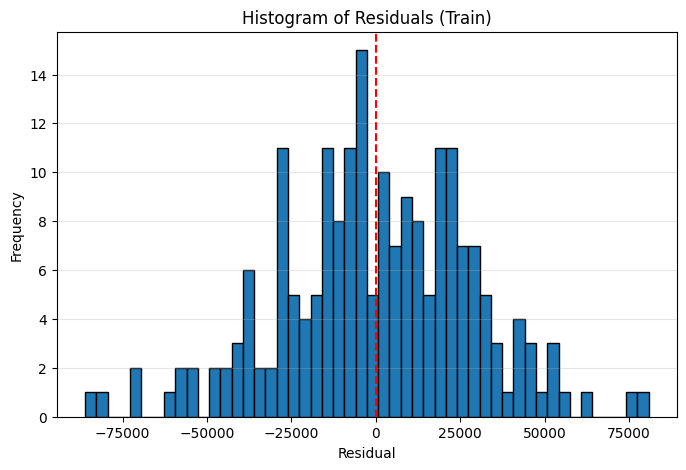

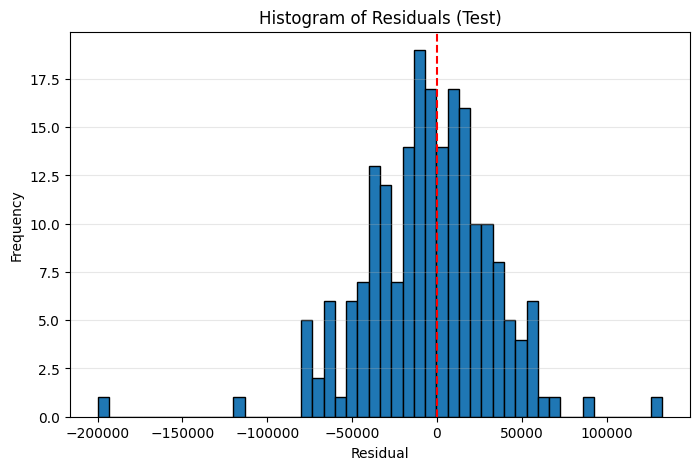

In [570]:
plt.figure(figsize=(8, 5))
plt.hist(y_train - predicted_train, bins=50, edgecolor='black')
plt.axvline(0, linestyle="--", color='red')

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.title("Histogram of Residuals (Train)")

plt.show()

plt.figure(figsize=(8, 5))
plt.hist(y_test - predicted_test, bins=50, edgecolor='black')
plt.axvline(0, linestyle="--", color='red')

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.title("Histogram of Residuals (Test)")

plt.show()

### Optional: generic solution

Use
```python
pipeline = Pipeline(steps=[
    ("encoder", ...),
    ...
    ("regressor", LinearRegression()),
])
```
to run all these steps with a simple `pipeline.fit(X_train, y_train)` and `pipeline.predict(X_test)`.

Use
```python
ColumnTransformer(
    transformers=[("prefix", step, list_of_columns)],
    remainder="passthrough",
)
```
to apply a step (like OneHotEncoder) to a subset of columns while leaving the rest unchanged. The resulting columns will be prefixed with the given string.
You can run `pipeline[i].get_feature_names_out()` to see the names of the features after each step.

Check out [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html).

In [571]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

In [572]:
feature_cols_generic = [
    "area",
    "build_year",
    "district",
    "bedrooms",
    "bathrooms",
    "parking"
]

numeric_cols = [
    "area",
    "build_year",
    "bedrooms",
    "bathrooms",
    "parking"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "district",
            OneHotEncoder(handle_unknown="ignore"),
            ["district"]
        ),
        (
            "poly",
            PolynomialFeatures(
                degree=2,
                include_bias=False
            ),
            numeric_cols
        )
    ]
)

X_train = train_df_clean[feature_cols_generic]
X_test = test_df_clean[feature_cols_generic]

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

print(X_train_transformed.shape)
print(X_test_transformed.shape)

print(preprocessor.get_feature_names_out())

(200, 6) (200,)
(205, 6) (205,)
(200, 24)
(205, 24)
['district__district_grodziskowo' 'district__district_mokotowo'
 'district__district_ochotowo' 'district__district_wolowo' 'poly__area'
 'poly__build_year' 'poly__bedrooms' 'poly__bathrooms' 'poly__parking'
 'poly__area^2' 'poly__area build_year' 'poly__area bedrooms'
 'poly__area bathrooms' 'poly__area parking' 'poly__build_year^2'
 'poly__build_year bedrooms' 'poly__build_year bathrooms'
 'poly__build_year parking' 'poly__bedrooms^2' 'poly__bedrooms bathrooms'
 'poly__bedrooms parking' 'poly__bathrooms^2' 'poly__bathrooms parking'
 'poly__parking^2']


In [573]:
lm2 = LinearRegression()
lm2.fit(X_train_transformed, y_train)
predicted_train = lm2.predict(X_train_transformed)
predicted_test = lm2.predict(X_test_transformed)

print("Train:")
print(f"MAE:  {mean_absolute_error(y_train, predicted_train):.2e}")
print(f"RMSE: {mean_squared_error(y_train, predicted_train) ** 0.5:.2e}")
print(f"R2:   {r2_score(y_train, predicted_train):.2e}")

print("\nTest:")
print(f"MAE:  {mean_absolute_error(y_test, predicted_test):.2e}")
print(f"RMSE: {mean_squared_error(y_test, predicted_test) ** 0.5:.2e}")
print(f"R2:   {r2_score(y_test, predicted_test):.2e}")


Train:
MAE:  5.02e+04
RMSE: 6.12e+04
R2:   9.49e-01

Test:
MAE:  5.31e+04
RMSE: 6.89e+04
R2:   9.42e-01


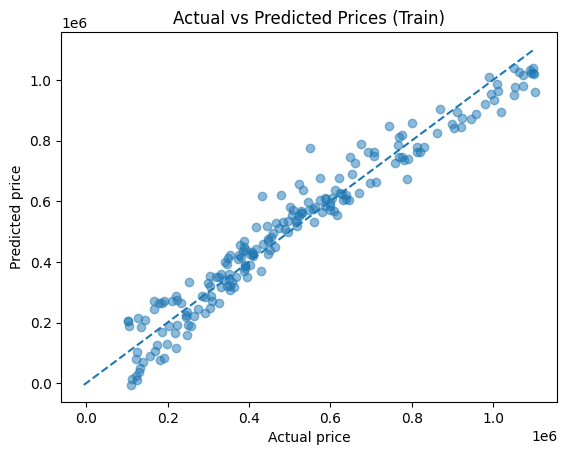

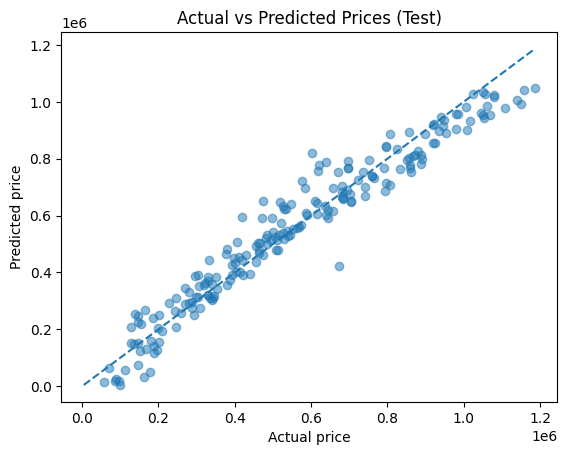

In [574]:
plt.scatter(y_train, predicted_train, alpha=0.5)

lims = [
    min(y_train.min(), predicted_train.min()),
    max(y_train.max(), predicted_train.max())
]
plt.plot(lims, lims, '--')

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted Prices (Train)")
plt.show()


plt.scatter(y_test, predicted_test, alpha=0.5)

lims = [
    min(y_test.min(), predicted_test.min()),
    max(y_test.max(), predicted_test.max())
]
plt.plot(lims, lims, '--')

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted Prices (Test)")
plt.show()

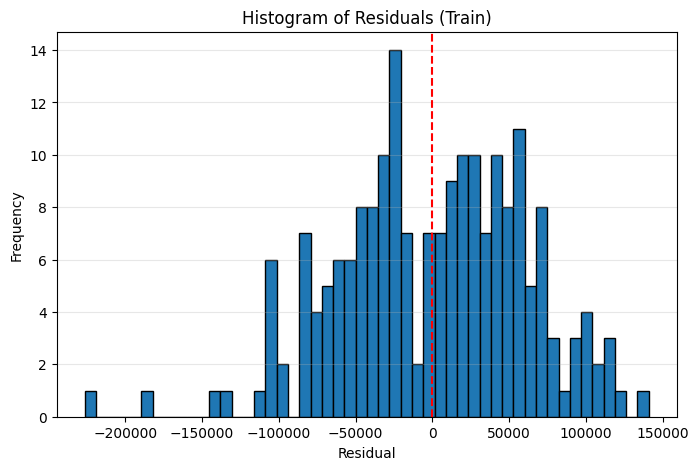

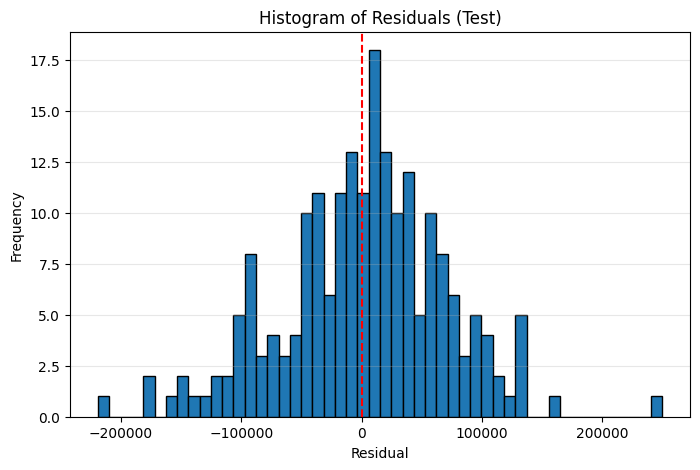

In [575]:
plt.figure(figsize=(8, 5))
plt.hist(y_train - predicted_train, bins=50, edgecolor='black')
plt.axvline(0, linestyle="--", color='red')

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.title("Histogram of Residuals (Train)")

plt.show()

plt.figure(figsize=(8, 5))
plt.hist(y_test - predicted_test, bins=50, edgecolor='black')
plt.axvline(0, linestyle="--", color='red')

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.title("Histogram of Residuals (Test)")

plt.show()

## Validation

In this exercise you will implement a validation pipeline: split the non-test set into train and validation sets and select the best model based on validation results.

So far you tested your model against the training and test datasets. As you should observe, there's a gap between the results. By validating your model, you should be able to better anticipate the test time performance and compare different models and hyperparameters on datasets they are not over-fitted to.

Implement the basic validation method, i.e. a random split.

In [576]:
def random_split(df: pd.DataFrame, val_ratio: float, seed: int) -> tuple[pd.DataFrame, pd.DataFrame]:
  "perform random split of the data frame"

  np.random.seed(seed)
  shuffled_indices = np.random.permutation(df.shape[0])
  split_index = int(df.shape[0] * (1 - val_ratio))

  train_df = df.iloc[shuffled_indices[:split_index]]
  val_df = df.iloc[shuffled_indices[split_index:]]

  return train_df, val_df

new_train_df, val_df = random_split(train_df_clean, val_ratio=0.2, seed=42)

In [577]:
### TODO ###

district_to_average = {}

for district in new_train_df['district'].unique():
    relevant = new_train_df.loc[new_train_df['district'] == district]
    district_to_average[district] = (
        relevant['price'].sum() / relevant['area'].sum()
    )

global_avg = new_train_df['price'].sum() / new_train_df['area'].sum()

handed_engineered_train = new_train_df.copy()
handed_engineered_val = val_df.copy()

handed_engineered_train['area_times_district_avg'] = (
    handed_engineered_train['area']
    * handed_engineered_train['district'].map(district_to_average)
)

handed_engineered_val['area_times_district_avg'] = (
    handed_engineered_val['area']
    * handed_engineered_val['district'].map(district_to_average).fillna(global_avg)
)

In [578]:
feature_cols_handed_engineered = [
    "area",
    "build_year",
    "area_times_district_avg",
    "district_embedded",
    "bedrooms",
    "bathrooms",
    "parking"
]

X_train = handed_engineered_train[feature_cols_handed_engineered].to_numpy()
y_train = handed_engineered_train['price'].to_numpy()

X_val = handed_engineered_val[feature_cols_handed_engineered].to_numpy()
y_val = handed_engineered_val['price'].to_numpy()

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(160, 7) (160,)
(40, 7) (40,)


In [579]:
lm = LinearRegression()
lm.fit(X_train, y_train)
predicted_train = lm.predict(X_train)
predicted_val = lm.predict(X_val)

print("Train:")
print(f"MAE:  {mean_absolute_error(y_train, predicted_train):.2e}")
print(f"RMSE: {mean_squared_error(y_train, predicted_train) ** 0.5:.2e}")
print(f"R2:   {r2_score(y_train, predicted_train):.2e}")

print("\nValidation:")
print(f"MAE:  {mean_absolute_error(y_val, predicted_val):.2e}")
print(f"RMSE: {mean_squared_error(y_val, predicted_val) ** 0.5:.2e}")
print(f"R2:   {r2_score(y_val, predicted_val):.2e}")


Train:
MAE:  2.37e+04
RMSE: 2.97e+04
R2:   9.89e-01

Validation:
MAE:  1.93e+04
RMSE: 2.42e+04
R2:   9.89e-01


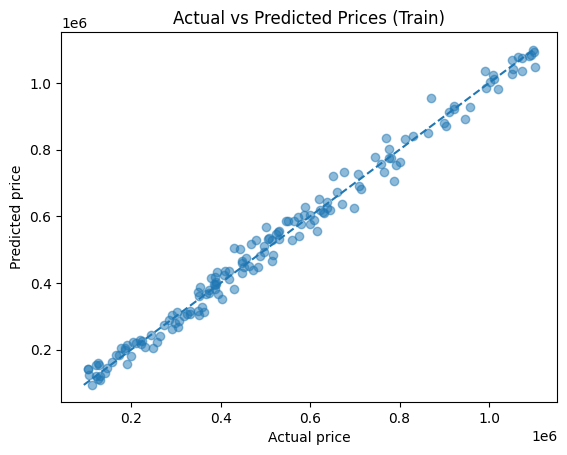

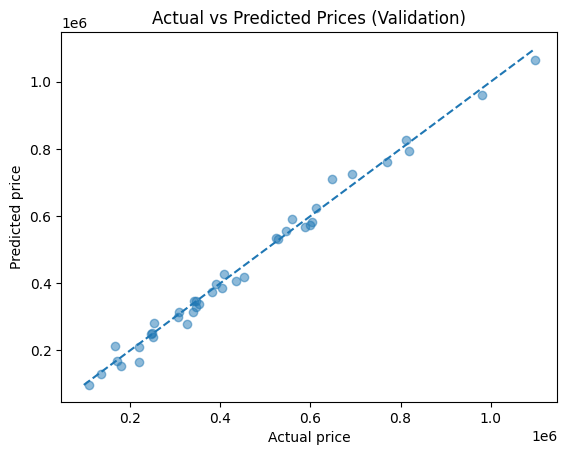

In [580]:
plt.scatter(y_train, predicted_train, alpha=0.5)

lims = [
    min(y_train.min(), predicted_train.min()),
    max(y_train.max(), predicted_train.max())
]
plt.plot(lims, lims, '--')

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted Prices (Train)")
plt.show()


plt.scatter(y_val, predicted_val, alpha=0.5)

lims = [
    min(y_val.min(), predicted_val.min()),
    max(y_val.max(), predicted_val.max())
]
plt.plot(lims, lims, '--')

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted Prices (Validation)")
plt.show()

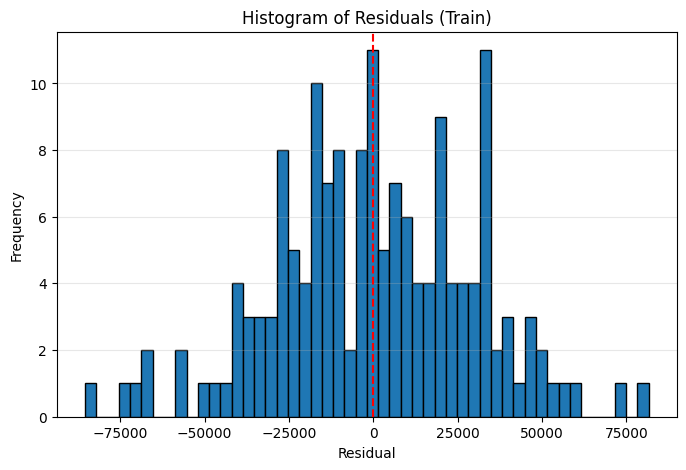

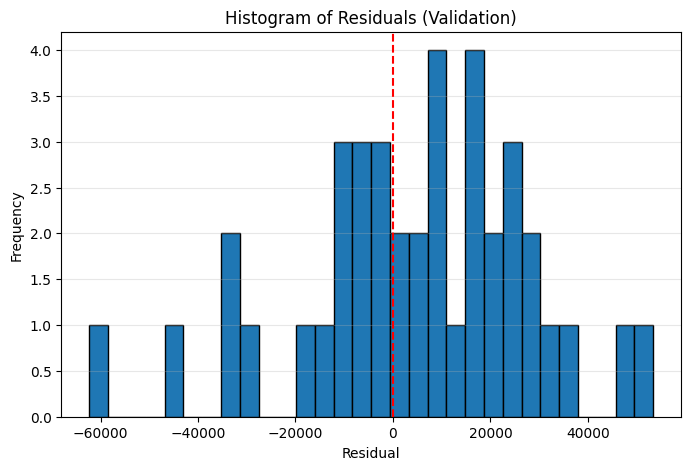

In [581]:
plt.figure(figsize=(8, 5))
plt.hist(y_train - predicted_train, bins=50, edgecolor='black')
plt.axvline(0, linestyle="--", color='red')

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.title("Histogram of Residuals (Train)")

plt.show()

plt.figure(figsize=(8, 5))
plt.hist(y_val - predicted_val, bins=30, edgecolor='black')
plt.axvline(0, linestyle="--", color='red')

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.title("Histogram of Residuals (Validation)")

plt.show()

In [582]:
X_train = new_train_df[feature_cols_generic]
X_val = val_df[feature_cols_generic]

X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

print(X_train_transformed.shape)
print(X_val_transformed.shape)

print(preprocessor.get_feature_names_out())

(160, 6) (160,)
(40, 6) (40,)
(160, 24)
(40, 24)
['district__district_grodziskowo' 'district__district_mokotowo'
 'district__district_ochotowo' 'district__district_wolowo' 'poly__area'
 'poly__build_year' 'poly__bedrooms' 'poly__bathrooms' 'poly__parking'
 'poly__area^2' 'poly__area build_year' 'poly__area bedrooms'
 'poly__area bathrooms' 'poly__area parking' 'poly__build_year^2'
 'poly__build_year bedrooms' 'poly__build_year bathrooms'
 'poly__build_year parking' 'poly__bedrooms^2' 'poly__bedrooms bathrooms'
 'poly__bedrooms parking' 'poly__bathrooms^2' 'poly__bathrooms parking'
 'poly__parking^2']


In [583]:
lm2 = LinearRegression()
lm2.fit(X_train_transformed, y_train)
predicted_train = lm2.predict(X_train_transformed)
predicted_val = lm2.predict(X_val_transformed)

print("Train:")
print(f"MAE:  {mean_absolute_error(y_train, predicted_train):.2e}")
print(f"RMSE: {mean_squared_error(y_train, predicted_train) ** 0.5:.2e}")
print(f"R2:   {r2_score(y_train, predicted_train):.2e}")

print("\nValidation:")
print(f"MAE:  {mean_absolute_error(y_val, predicted_val):.2e}")
print(f"RMSE: {mean_squared_error(y_val, predicted_val) ** 0.5:.2e}")
print(f"R2:   {r2_score(y_val, predicted_val):.2e}")


Train:
MAE:  5.09e+04
RMSE: 6.12e+04
R2:   9.52e-01

Validation:
MAE:  5.78e+04
RMSE: 7.05e+04
R2:   9.07e-01


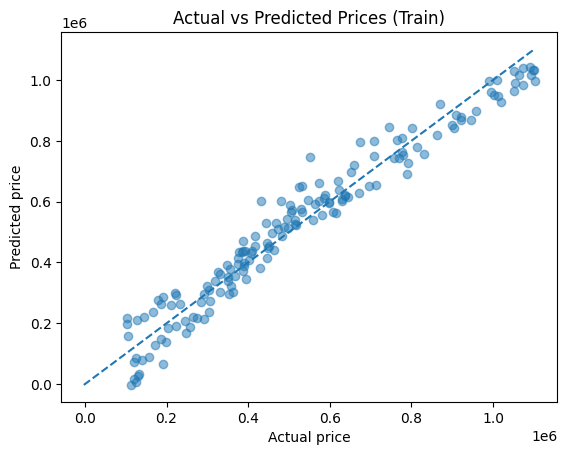

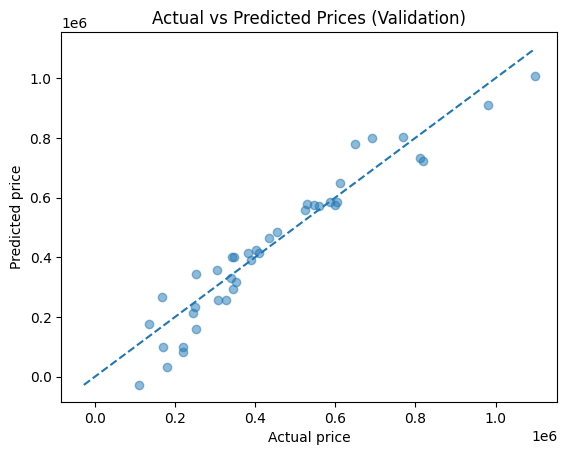

In [584]:
plt.scatter(y_train, predicted_train, alpha=0.5)

lims = [
    min(y_train.min(), predicted_train.min()),
    max(y_train.max(), predicted_train.max())
]
plt.plot(lims, lims, '--')

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted Prices (Train)")
plt.show()


plt.scatter(y_val, predicted_val, alpha=0.5)

lims = [
    min(y_val.min(), predicted_val.min()),
    max(y_val.max(), predicted_val.max())
]
plt.plot(lims, lims, '--')

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted Prices (Validation)")
plt.show()

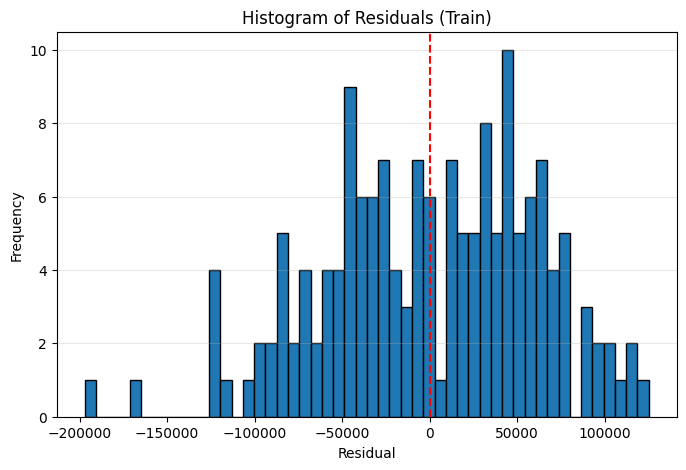

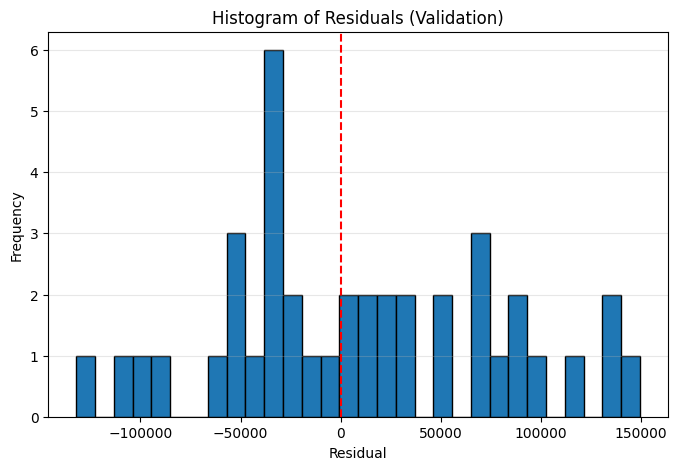

In [585]:
plt.figure(figsize=(8, 5))
plt.hist(y_train - predicted_train, bins=50, edgecolor='black')
plt.axvline(0, linestyle="--", color='red')

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.title("Histogram of Residuals (Train)")

plt.show()

plt.figure(figsize=(8, 5))
plt.hist(y_val - predicted_val, bins=30, edgecolor='black')
plt.axvline(0, linestyle="--", color='red')

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.title("Histogram of Residuals (Validation)")

plt.show()

## Cross-validation

To make the random split validation reliable, a significant chunk of training data may be needed. To get over this problem, one may apply cross-validation.

![alt-text](https://chrisjmccormick.files.wordpress.com/2013/07/10_fold_cv.png)

Implement a k-fold cross-validation method.

In [589]:
def kfold(df: pd.DataFrame, k: int = 5, shuffle: bool = True) -> list[float]:
  """Returns a list of validation losses for each of k folds."""

  new_train_df, val_df = random_split(df, val_ratio=0.2, seed=42)
  val_losses = []

  if shuffle:
    val_df = val_df.sample(frac=1, random_state=42)

  folds = np.array_split(val_df, k)

  for i in range(k):
    curr_val_df = folds[i].copy()

    curr_train_df = pd.concat([new_train_df] + folds[:i] + folds[i + 1:]).copy()

    district_to_average = {}

    for district in curr_train_df['district'].unique():
      relevant = curr_train_df.loc[curr_train_df['district'] == district]
      district_to_average[district] = relevant['price'].sum() / relevant['area'].sum()

    global_avg = curr_train_df['price'].sum() / curr_train_df['area'].sum()
    curr_train_df['area_times_district_avg'] = curr_train_df['area'] * curr_train_df['district'].map(district_to_average)
    curr_val_df['area_times_district_avg'] = curr_val_df['area'] * curr_val_df['district'].map(district_to_average).fillna(global_avg)

    X_train = curr_train_df[feature_cols_handed_engineered].to_numpy()
    y_train = curr_train_df['price'].to_numpy()

    X_val = curr_val_df[feature_cols_handed_engineered].to_numpy()
    y_val = curr_val_df['price'].to_numpy()

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    print(f"    RMSE: {rmse:9_.0f}")
    val_losses.append(float(rmse))

  return val_losses

losses = kfold(train_df_clean)
print(f"k-fold loss (hand engineered): {np.mean(losses):_.0f} ± {np.std(losses):_.0f}")

    RMSE:    15_595
    RMSE:    24_659
    RMSE:    31_328
    RMSE:    23_715
    RMSE:    18_854
k-fold loss (hand engineered): 22_830 ± 5_376


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [590]:
def kfold2(df: pd.DataFrame, k: int = 5, shuffle: bool = True) -> list[float]:
  """Returns a list of validation losses for each of k folds."""

  new_train_df, val_df = random_split(df, val_ratio=0.2, seed=42)
  val_losses = []

  if shuffle:
    val_df = val_df.sample(frac=1, random_state=42)

  folds = np.array_split(val_df, k)

  for i in range(k):
    curr_train_df = pd.concat([new_train_df] + folds[:i] + folds[i + 1:]).copy()
    curr_val_df = folds[i].copy()

    X_train = curr_train_df[feature_cols_generic]
    y_train = curr_train_df['price'].to_numpy()

    X_val = curr_val_df[feature_cols_generic]
    y_val = curr_val_df['price'].to_numpy()

    X_train_transformed = preprocessor.fit_transform(X_train)
    X_val_transformed = preprocessor.transform(X_val)

    model = LinearRegression()
    model.fit(X_train_transformed, y_train)

    y_val_pred = model.predict(X_val_transformed)

    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    print(f"    RMSE: {rmse:9_.0f}")
    val_losses.append(float(rmse))

  return val_losses

losses = kfold2(train_df_clean)
print(f"k-fold loss (generic): {np.mean(losses):_.0f} ± {np.std(losses):_.0f}")

    RMSE:    43_248
    RMSE:    80_899
    RMSE:    71_710
    RMSE:    61_925
    RMSE:    50_917
k-fold loss (generic): 61_740 ± 13_606


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
